Budge analysis

Loaded: ../cleaned_archive/movies_metadata_box_office.csv | Rows: 5356


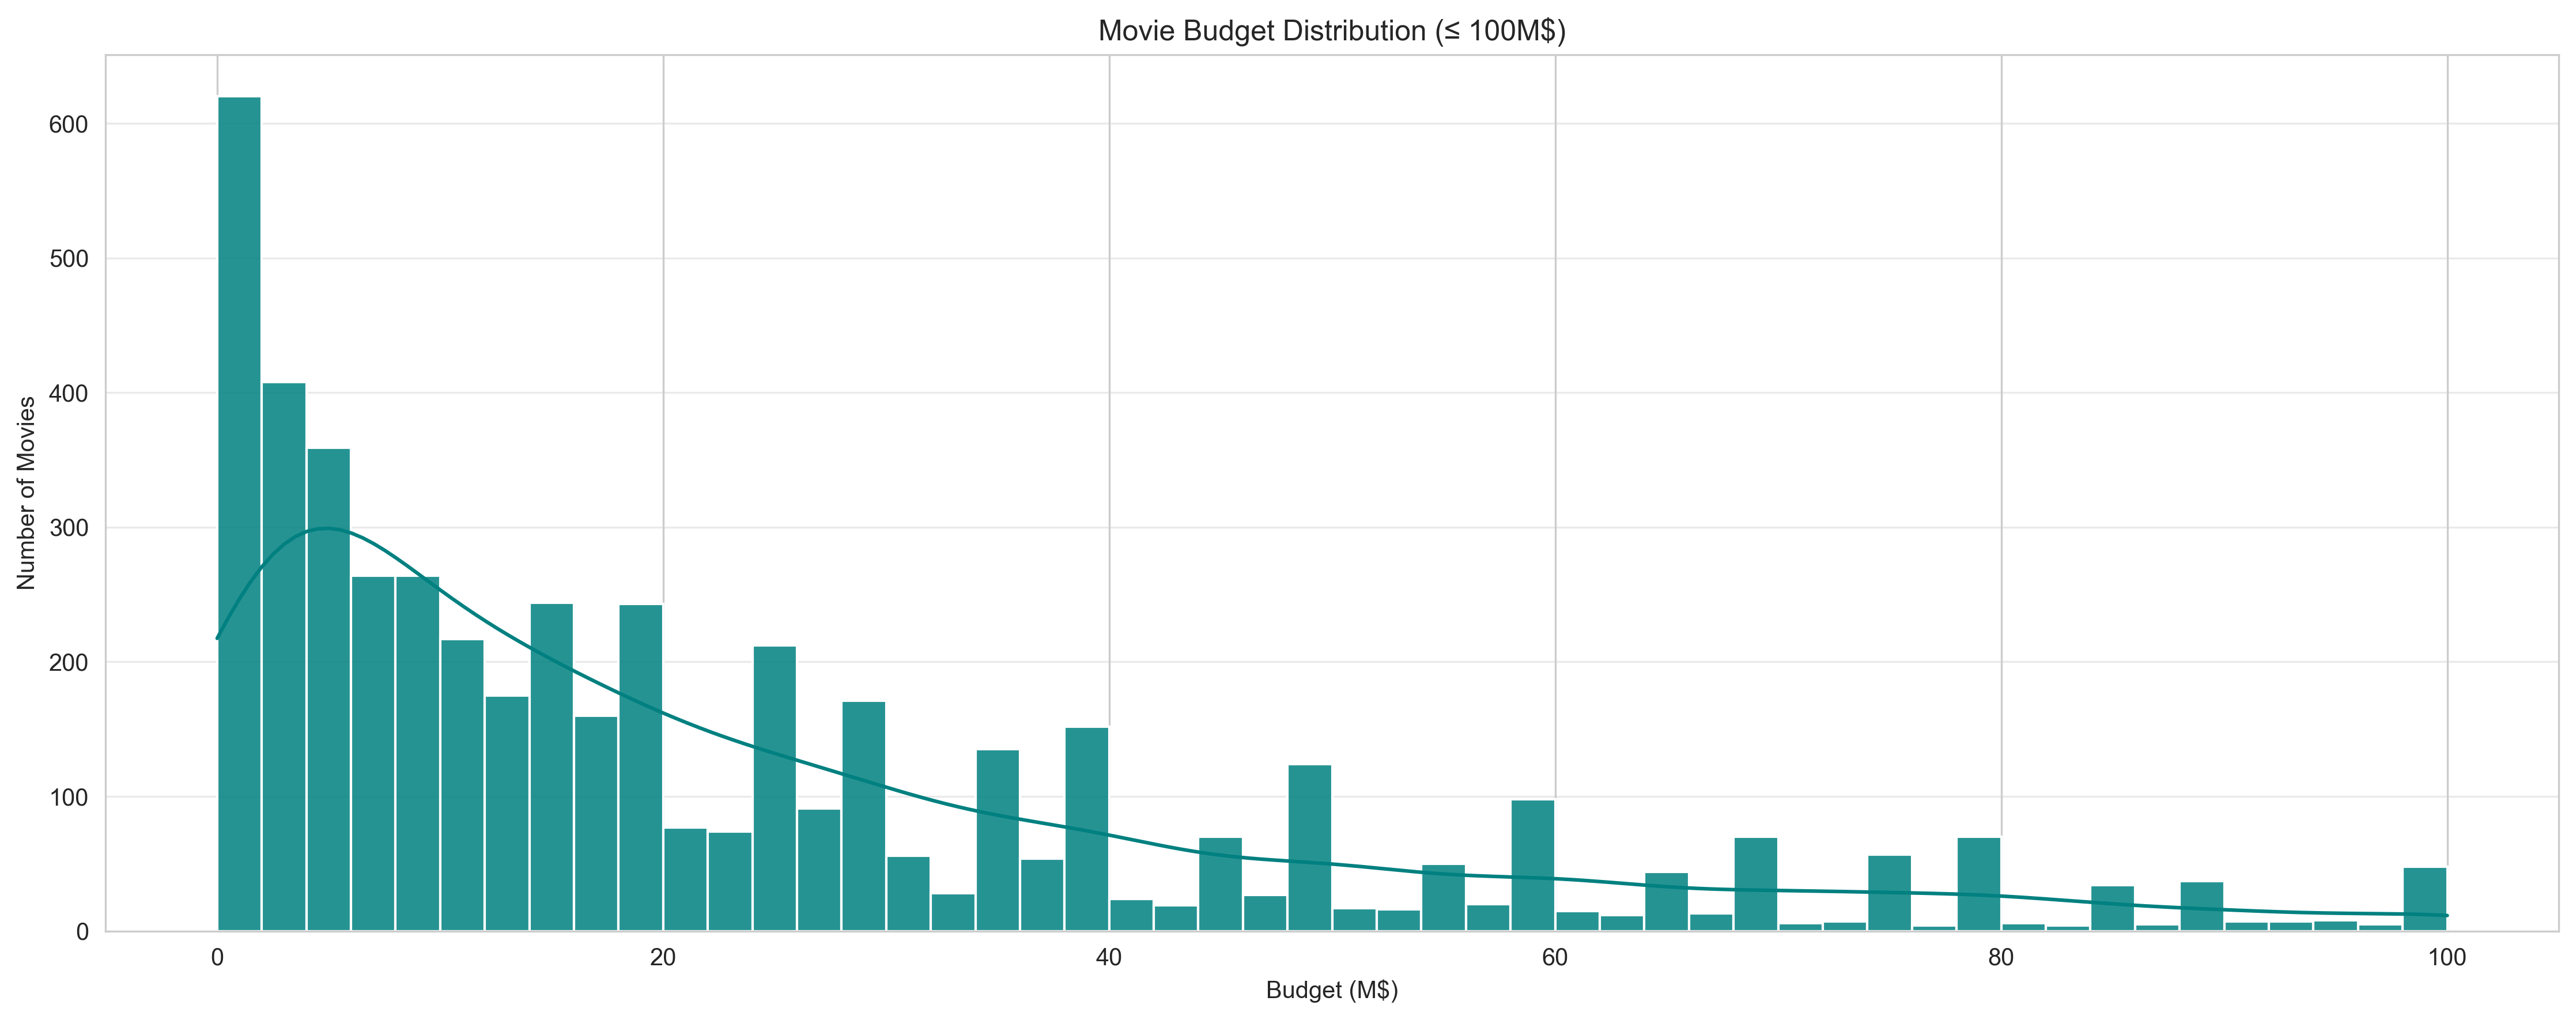

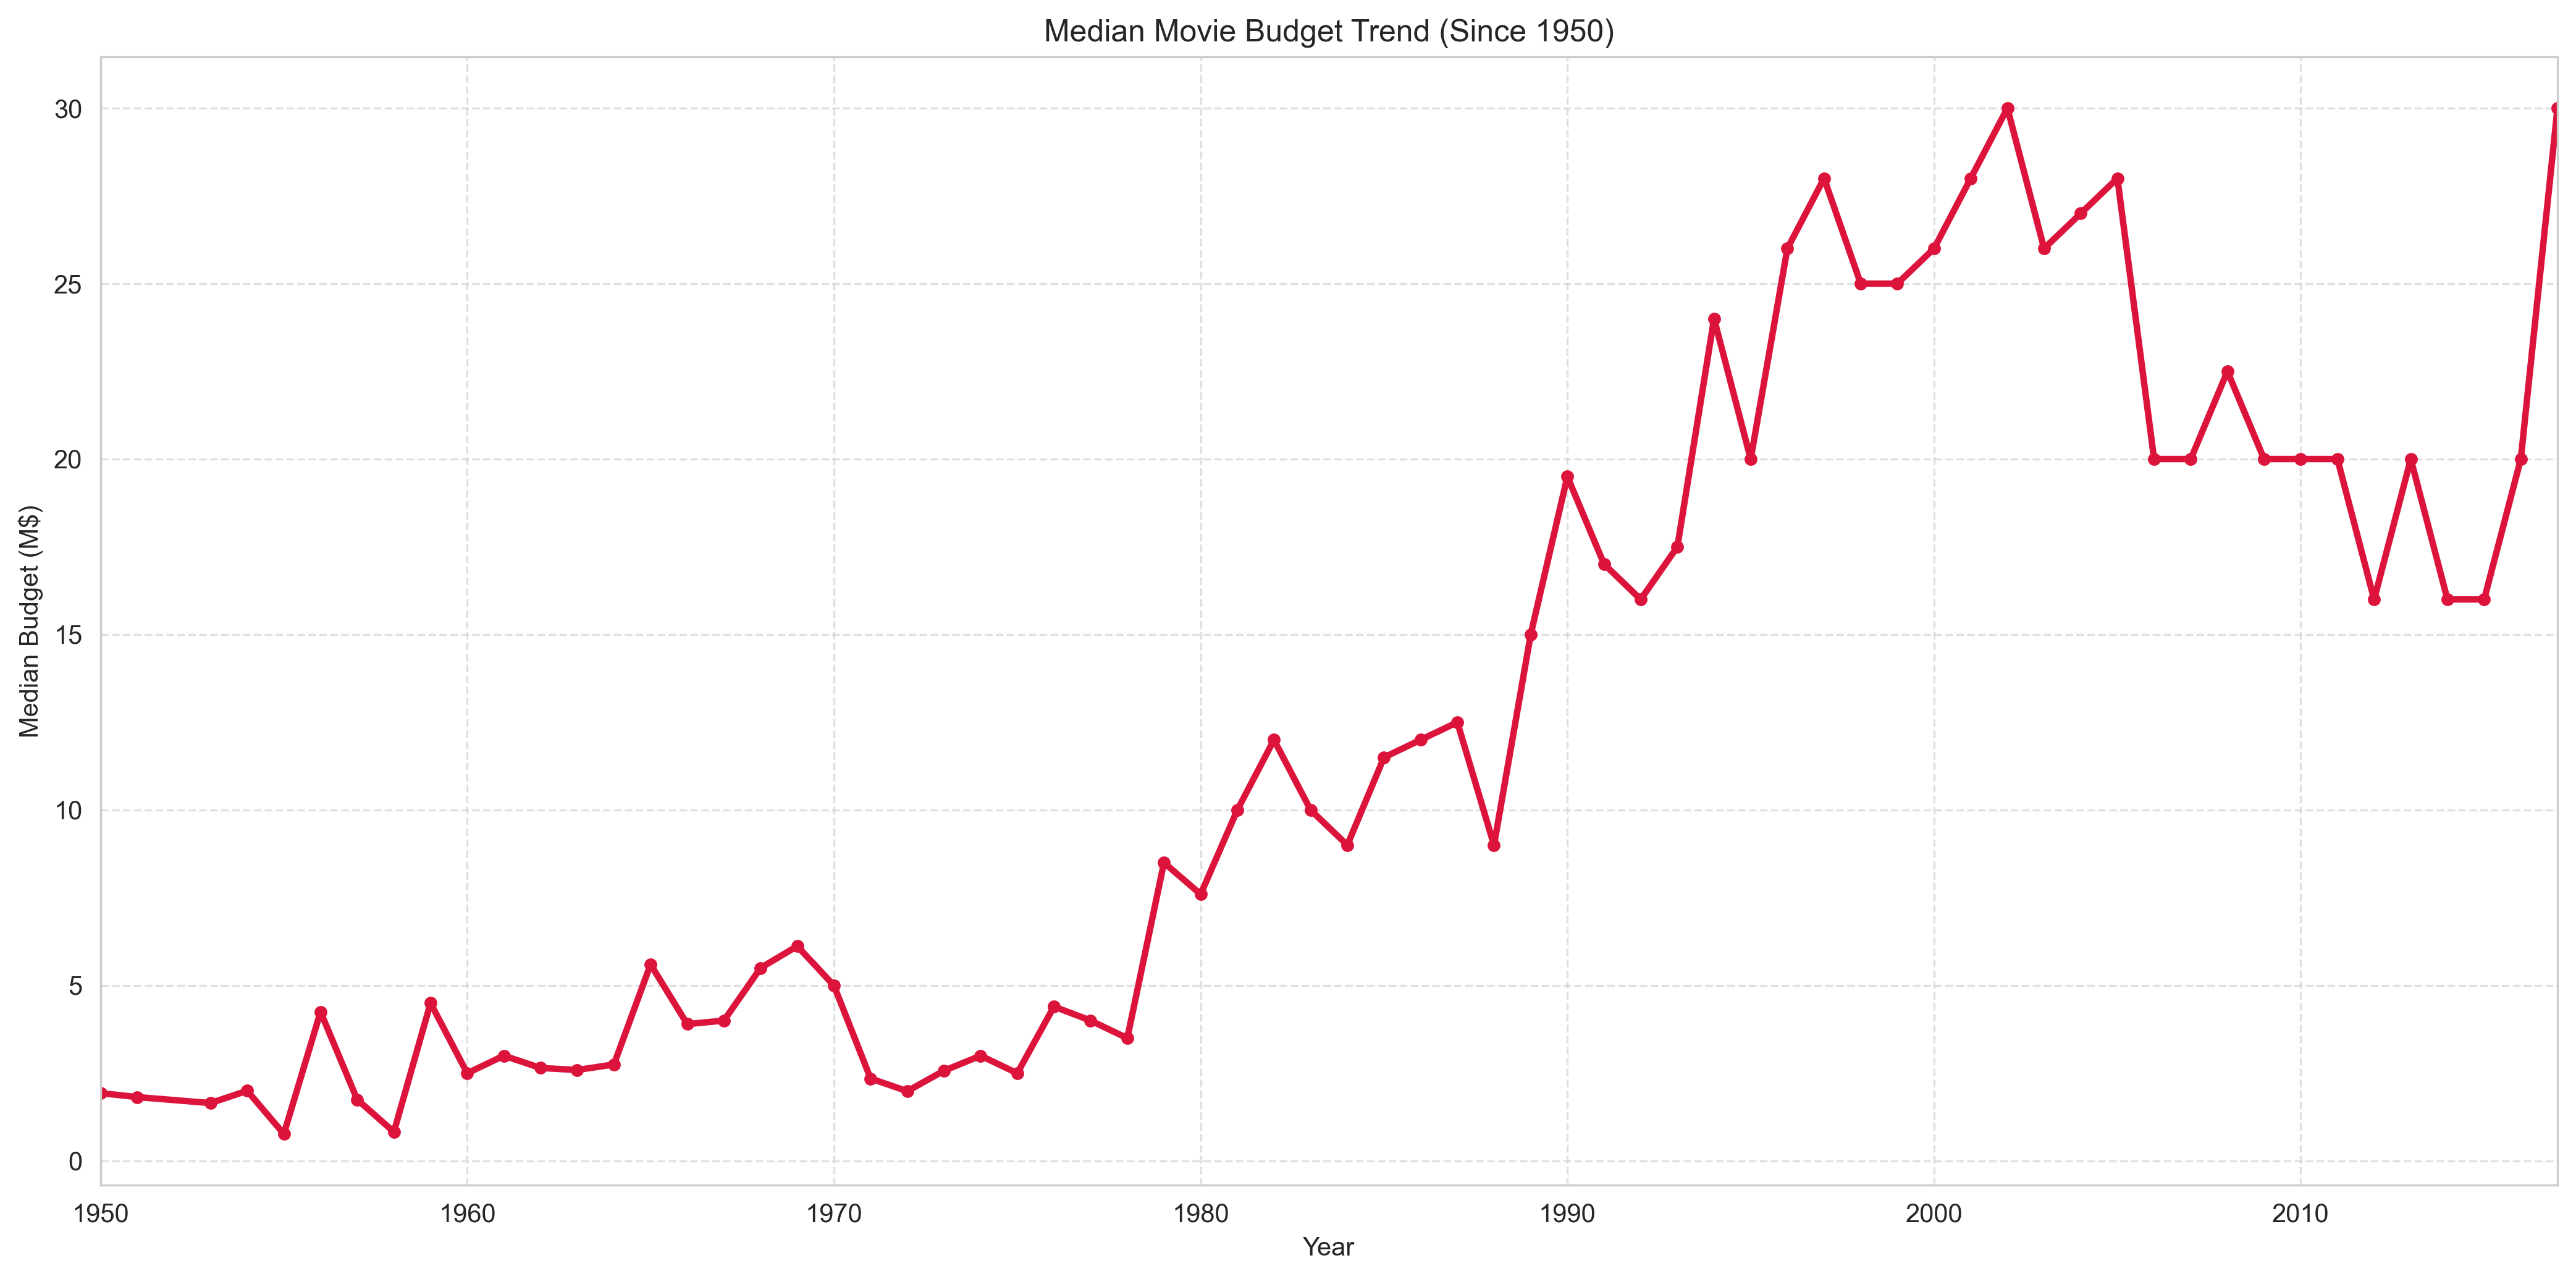

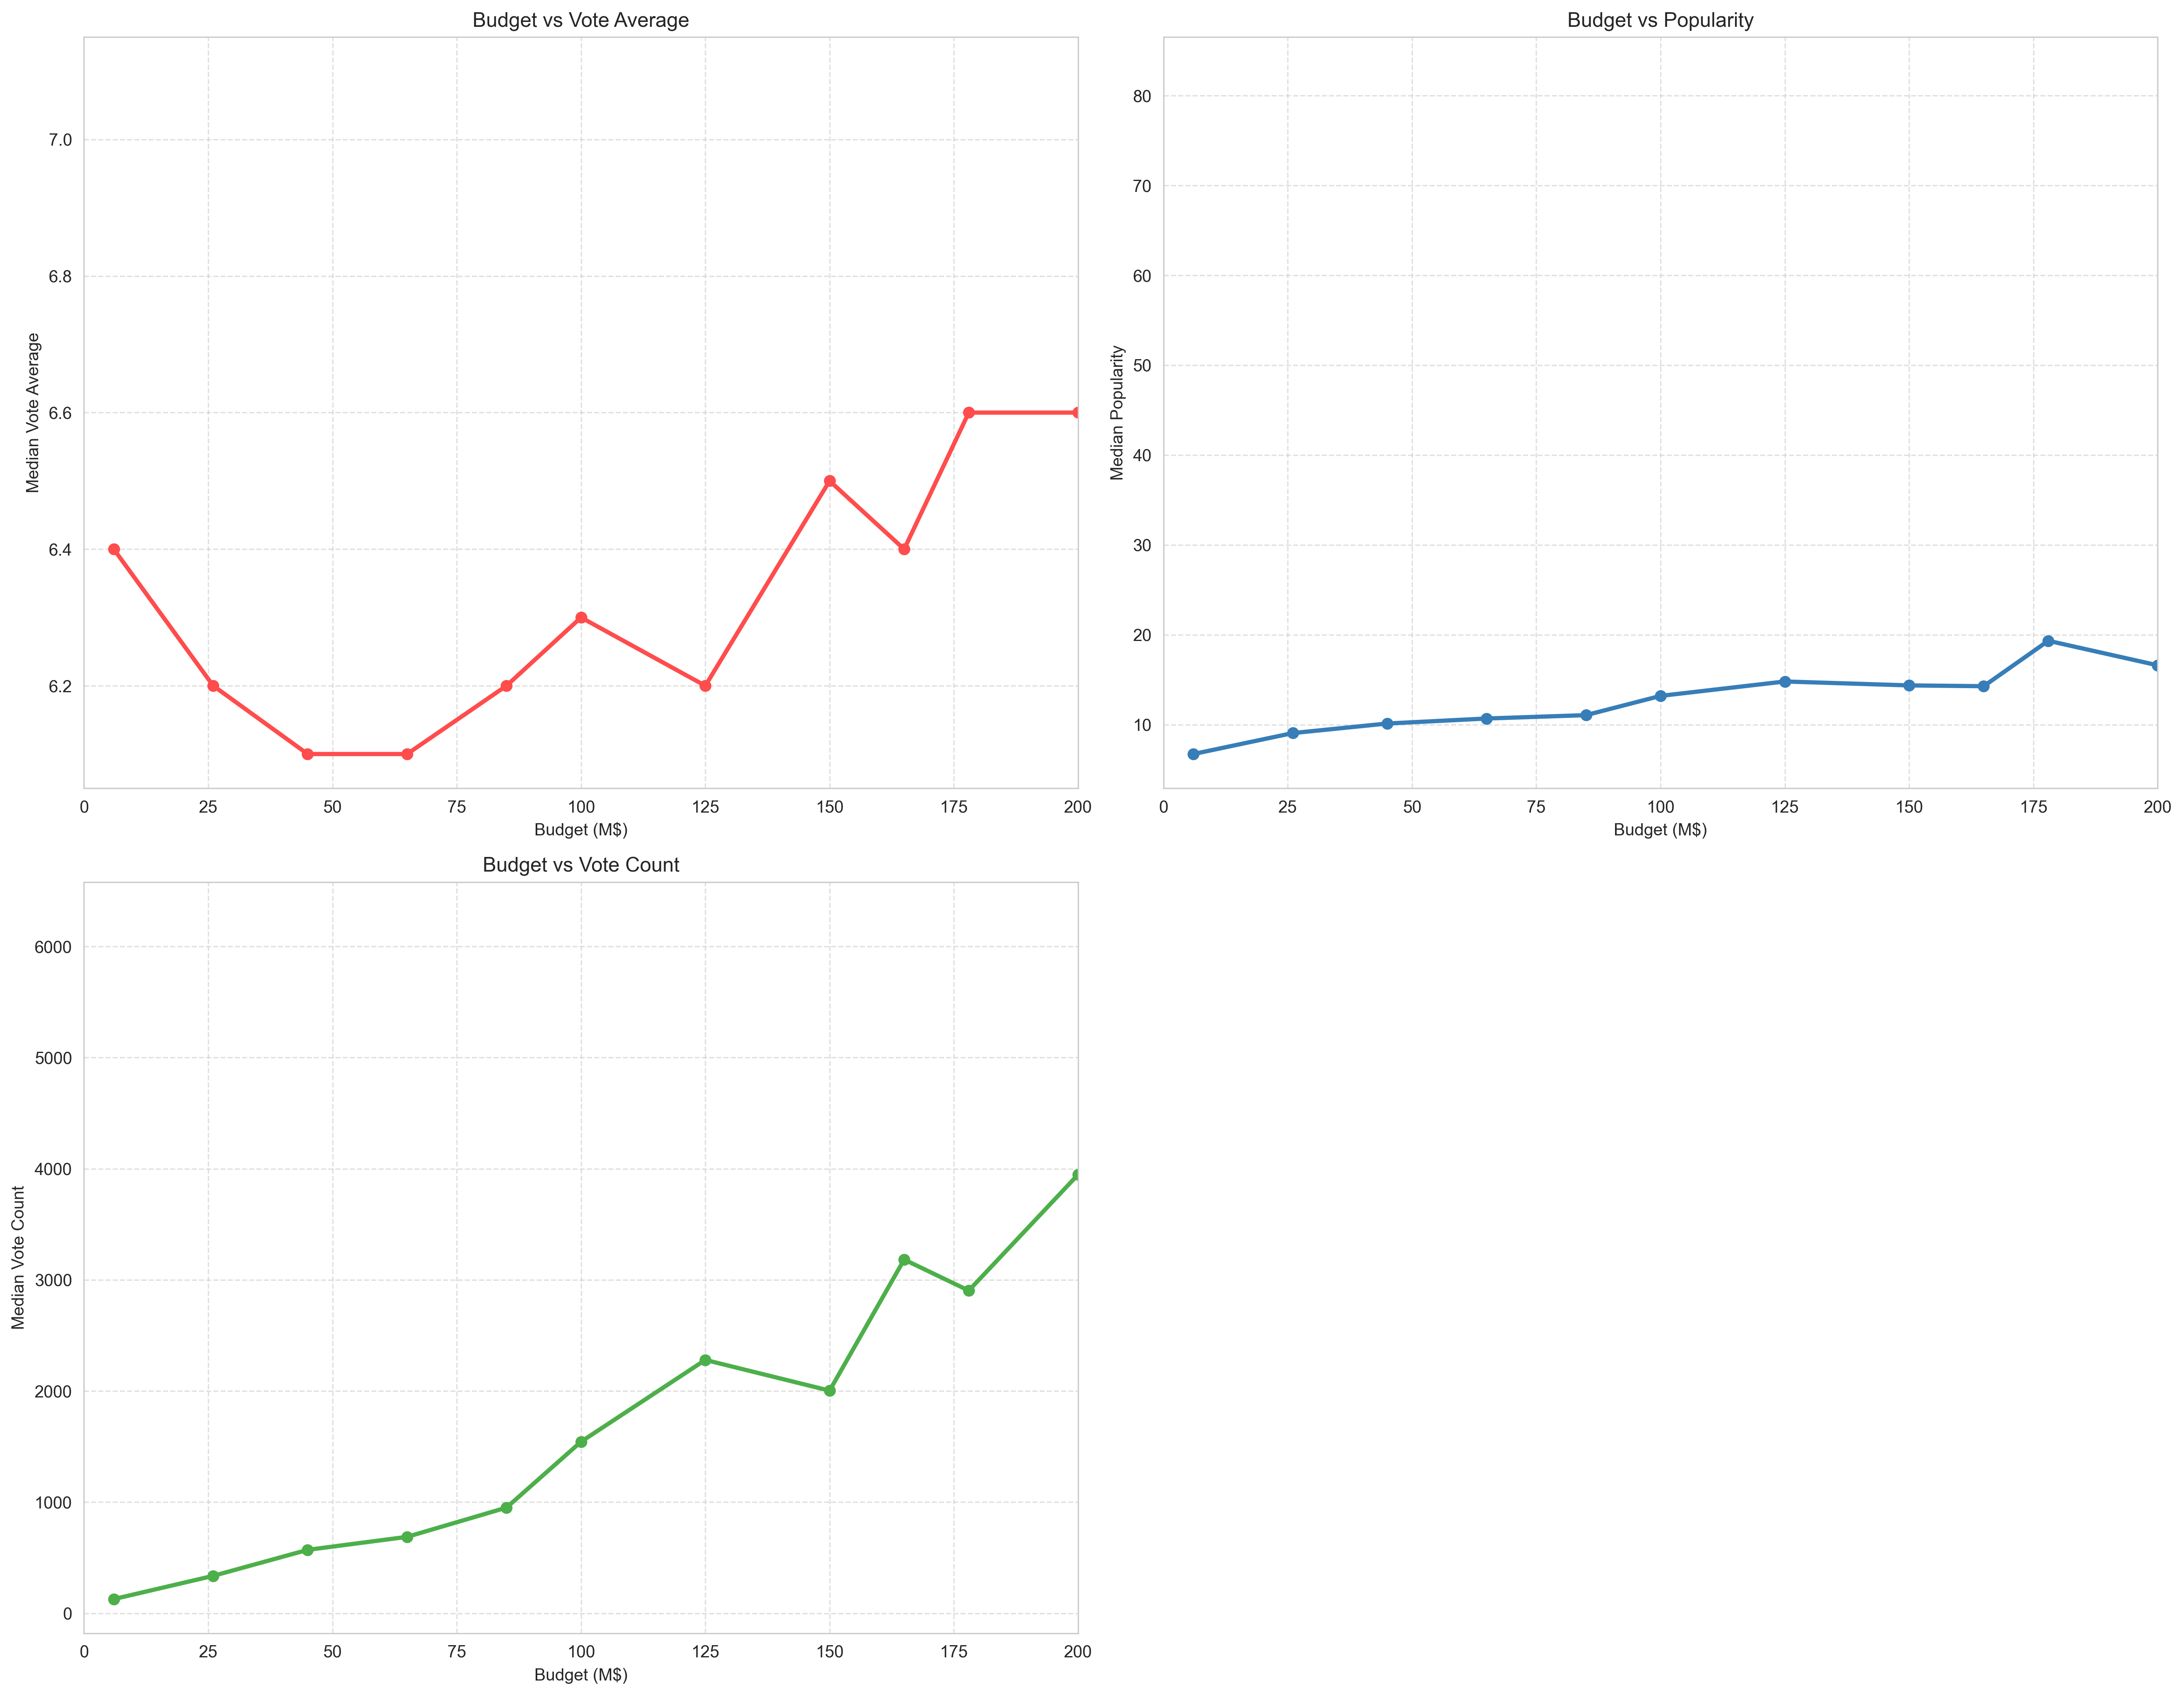

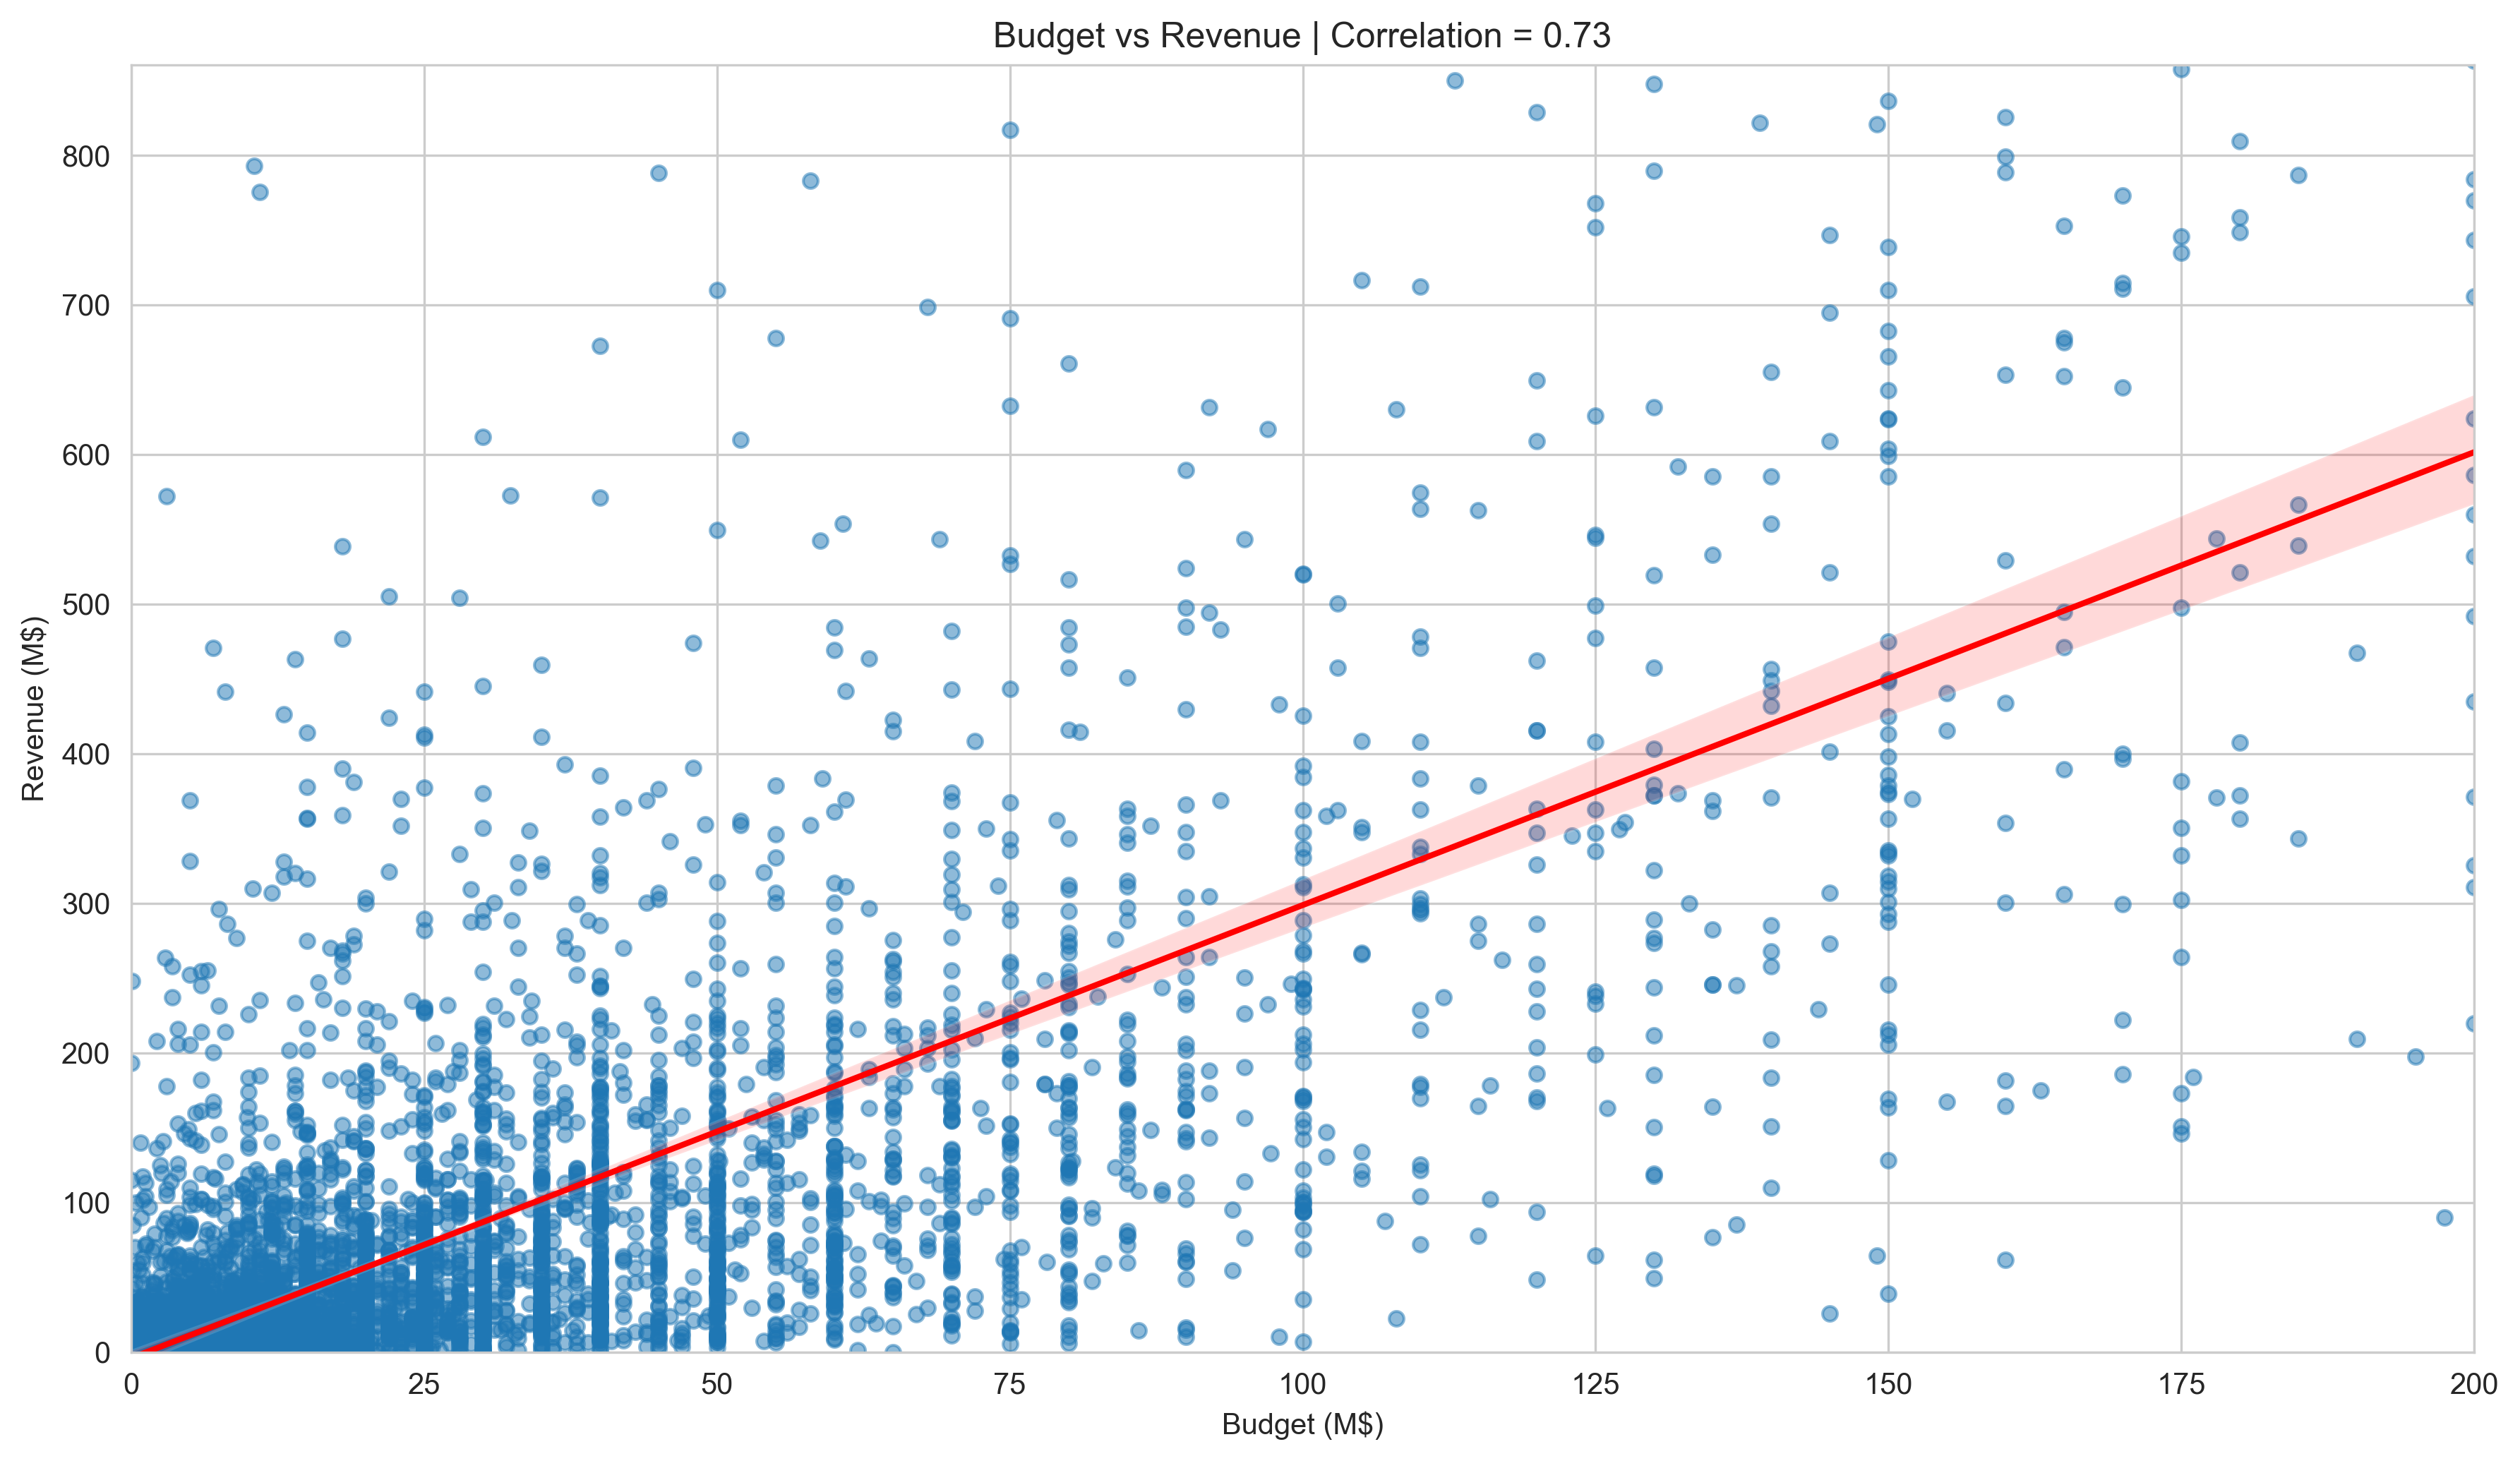

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 300

file_name = '../cleaned_archive/movies_metadata_box_office.csv'

df = pd.read_csv(file_name)
print(f"Loaded: {file_name} | Rows: {len(df)}")

df['budget'] = df['budget'].replace(0, np.nan)
df['revenue'] = df['revenue'].replace(0, np.nan)

df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['release_year'] = df['release_date'].dt.year

df_final = df.dropna(subset=['budget', 'release_year', 'vote_average', 'vote_count', 'popularity']).copy()
df_final['budget_M'] = df_final['budget'] / 1_000_000

df_budget_analysis = df_final[df_final['release_year'] >= 1950].copy()

max_budget_M = 100
data_hist = df_budget_analysis[df_budget_analysis['budget_M'] <= max_budget_M]['budget_M']

plt.figure(figsize=(15, 6))
sns.histplot(data_hist, bins=50, color='teal', edgecolor='white', alpha=0.85, kde=True)
plt.title(f'Movie Budget Distribution (≤ {max_budget_M}M$)')
plt.xlabel('Budget (M$)')
plt.ylabel('Number of Movies')
plt.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

budget_trend = df_budget_analysis.groupby('release_year').agg(
    Median_Budget_M=('budget_M', 'median'),
    Count=('id', 'count')
).reset_index()
budget_trend = budget_trend[budget_trend['Count'] >= 5]

plt.figure(figsize=(14, 7))
plt.plot(budget_trend['release_year'], budget_trend['Median_Budget_M'],
         marker='o', linewidth=2.5, color='crimson', markersize=4)
plt.title('Median Movie Budget Trend (Since 1950)')
plt.xlabel('Year')
plt.ylabel('Median Budget (M$)')
plt.xticks(np.arange(1950, budget_trend['release_year'].max() + 1, 10))
plt.xlim(1950, budget_trend['release_year'].max())
plt.grid(linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

df_budget_analysis['budget_bin'] = pd.cut(df_budget_analysis['budget'], bins=20, labels=False)
budget_mid = df_budget_analysis.groupby('budget_bin')['budget_M'].median().reset_index()

metrics = ['vote_average', 'popularity', 'vote_count']
labels = ['Vote Average', 'Popularity', 'Vote Count']
colors = ['#ff4c4c', '#377eb8', '#4daf4a']

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flatten()

for i, (col, label, color) in enumerate(zip(metrics, labels, colors)):
    med = df_budget_analysis.groupby('budget_bin')[col].median().reset_index()
    merged = pd.merge(budget_mid, med, on='budget_bin')

    axes[i].plot(merged['budget_M'], merged[col], marker='o', linewidth=2.5, color=color)
    axes[i].set_title(f'Budget vs {label}')
    axes[i].set_xlabel('Budget (M$)')
    axes[i].set_ylabel(f'Median {label}')
    axes[i].grid(linestyle='--', alpha=0.6)
    max_x = df_budget_analysis['budget_M'].quantile(0.99)
    axes[i].set_xlim(0, max_x)

fig.delaxes(axes[3])
plt.tight_layout()
plt.show()

df_rev = df_budget_analysis.dropna(subset=['revenue']).copy()
df_rev['revenue_M'] = df_rev['revenue'] / 1_000_000

plt.figure(figsize=(12,7))
sns.regplot(
    x='budget_M', y='revenue_M', data=df_rev,
    scatter_kws={'alpha':0.5, 's':25},
    line_kws={'color':'red', 'linewidth':2},
    ci=95
)
corr = df_rev['budget_M'].corr(df_rev['revenue_M'])
plt.title(f'Budget vs Revenue | Correlation = {corr:.2f}')
plt.xlabel('Budget (M$)')
plt.ylabel('Revenue (M$)')
plt.xlim(0, df_rev['budget_M'].quantile(0.99))
plt.ylim(0, df_rev['revenue_M'].quantile(0.99))
plt.tight_layout()
plt.show()